<a href="https://colab.research.google.com/github/ElviraGD-lab/pajares-mountain-corridor-baseline/blob/main/notebooks/02_climate_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Extract a Temperature Time-Series

[TerraClimate](https://www.climatologylab.org/terraclimate.html) is long-term climatology dasaset that provides monthly-aggregated gridded data from 1950-present. It is hosted on a THREDDS Data Server (TDS) and served using the OPeNDAP (Open Data Access Protocol) protocol. XArray has built-in support to efficiently read and process OPeNDAP data where we can stream and process only the required pixels without downloading entire dataset.

Your task is to access the TerraClimate Monthly Maximum Temperature dataset and extract a time-series showing the temperatures at your chosen location from 1970-2025.

![](https://courses.spatialthoughts.com/images/python_remote_sensing/terraclimate.png)

Notes:

* Explore the [TerraClimate Catalog](http://thredds.northwestknowledge.net:8080/thredds/terraclimate_aggregated.html) on the THREDDS Data Server for all available datasets. This notebook providers code snippets below to show the access pattern.
* Use XArray's indexing methods to select the required subset from 1970-2025.


Make sure to install the `netCDF4` package for XArray to access NetCDF format data.

In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.5 MB/s eta 0:00:00


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

Mounted at /content/drive
Environment: colab
Data folder: /content/drive/MyDrive/python-remote-sensing
Output folder: /content/drive/MyDrive/python-remote-sensing


In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray \
        dask['distributed'] jupyter-server-proxy xrscipy

In [ ]:
import dask
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
import xrscipy.signal as xrs
from odc.stac import configure_s3_access, load

Import all required libraries.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36737
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44935'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37317'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35151 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35151
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:33546
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35697 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35697
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:33562
INFO:distributed.scheduler:Receive client connection: Client-268bcb55-b0ca-11f1-851c-0242ac1c000c
INFO:distributed.core:Starting establish

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36737,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35151,Total threads: 1
Dashboard: http://127.0.0.1:40101/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:44935,


In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

https://8787-m-s-kkb-use1d1-m2ldqq0x0xi7-d.us-east1-1.prod.colab.dev


In [ ]:
LATITUDE = 43.0000
LONGITUDE = -5.7600

point = ds.tmax.sel(lat=LATITUDE, lon=LONGITUDE, method='nearest')

In [ ]:
terraclimate_url = 'http://thredds.northwestknowledge.net:8080/thredds/dodsC/'
variable = 'tmax'
filename = f'agg_terraclimate_{variable}_1950_CurrentYear_GLOBE.nc'
remote_file_path = os.path.join(terraclimate_url, filename)
ds = xr.open_dataset(
    remote_file_path,
    chunks='auto',
    engine='netcdf4',
)
ds

<xarray.Dataset> Size: 272GB
Dimensions:  (time: 912, lat: 4320, lon: 8640, crs: 1)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * crs      (crs) int16 2B 3
Data variables:
    tmax     (time, lat, lon) float64 272GB dask.array<chunksize=(72, 341, 682), meta=np.ndarray>
Attributes: (12/49)
    method:                          These layers from TerraClimate were crea...
    version:                         V1.1
    title:                           TerraClimate: monthly climate and climat...
    summary:                         This archive contains a dataset of high-...
    keywords:                        WORLDCLIM,global,monthly, temperature,pr...
    id:                              Blank
    ...                              ...
    geospatial_vertical_positive:    Up
    Conventions:                     CF-1.6
    NCO:                             netCDF Operators version 4.8.1 (Homepage...
    source:                          WorldClim v2.1, ERA5
    references:                      Abatzoglou, J.T., Hegewisch, K.C., Yin, ...
    license:                         CC0 1.0 (https://creativecommons.org/pub...

In [ ]:
print(f'Requested: lat={LATITUDE:.4f}, lon={LONGITUDE:.4f}')
print(f'Got:       lat={float(point.lat):.4f}, lon={float(point.lon):.4f}')

# Cell size is 1/24 degree, so the centre can be up to ~2.3 km away.
d_lat_km = abs(float(point.lat) - LATITUDE) * 111
d_lon_km = abs(float(point.lon) - LONGITUDE) * 81
print(f'Offset:    {d_lat_km:.2f} km north-south, {d_lon_km:.2f} km east-west')

Requested: lat=43.0000, lon=-5.7600
Got:       lat=42.9792, lon=-5.7708
Offset:    2.31 km north-south, 0.88 km east-west


In [ ]:
series = point.sel(time=slice('1970-01-01', '2025-12-31'))
print(f'{len(series)} monthly values, '
      f'{str(series.time.values[0])[:7]} to {str(series.time.values[-1])[:7]}')

672 monthly values, 1970-01 to 2025-12


In [ ]:
# The nearest cell centre sits 2.3 km south of the pass, on the León side of
# the divide. Compare with the cell to the north, on the Asturian side.
north = ds.tmax.sel(lat=LATITUDE + 0.0417, lon=LONGITUDE, method='nearest')
north = north.sel(time=slice('1970-01-01', '2025-12-31')).compute()

print(f'South cell (used): lat={float(series.lat):.4f}  '
      f'mean={float(series.mean()):.2f} degC')
print(f'North cell:        lat={float(north.lat):.4f}  '
      f'mean={float(north.mean()):.2f} degC')
print(f'Difference:        {float(series.mean() - north.mean()):.2f} degC')

South cell (used): lat=42.9792  mean=12.32 degC
North cell:        lat=43.0625  mean=15.60 degC
Difference:        -3.28 degC


In [ ]:
print(f'min  = {float(series.min()):6.2f} degC')
print(f'max  = {float(series.max()):6.2f} degC')
print(f'mean = {float(series.mean()):6.2f} degC')
print(f'NaN  = {int(series.isnull().sum())}')

min  =   0.40 degC
max  =  25.40 degC
mean =  12.32 degC
NaN  = 0


In [ ]:
print(ds.tmax.attrs['units'])        # degC
print(ds.tmax.attrs['description'])  # Maximum 2-m Temperature

degC
Maximum 2-m Temperature


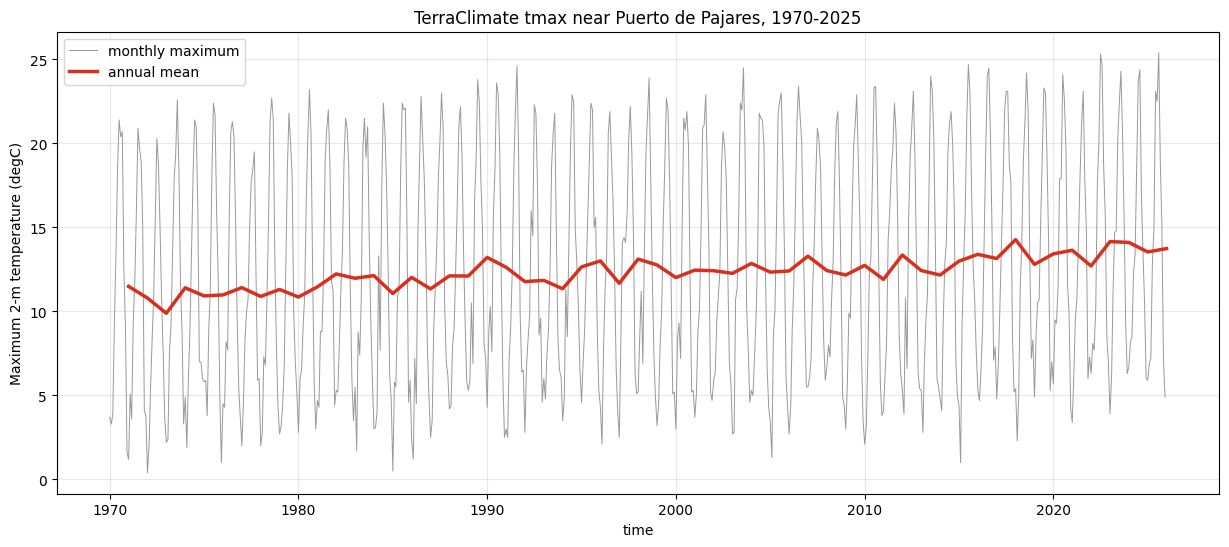

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 6)

series.plot.line(ax=ax, x='time', linewidth=0.7, color='#999999',
                 label='monthly maximum')

# Annual mean of monthly maxima. Smooths the seasonal cycle so the
# long-term change becomes visible.
annual = series.resample(time='YE').mean()
annual.plot.line(ax=ax, x='time', linewidth=2.5, color='#d7301f',
                 label='annual mean')

ax.set_ylabel('Maximum 2-m temperature (degC)')
ax.set_title('TerraClimate tmax near Puerto de Pajares, 1970-2025')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [ ]:
years = annual.time.dt.year.values
values = annual.values

slope, intercept = np.polyfit(years, values, 1)
print(f'Trend: {slope * 10:+.2f} degC per decade')
print(f'Total change 1970-2025: {slope * 55:+.2f} degC')

Trend: +0.48 degC per decade
Total change 1970-2025: +2.66 degC


In [ ]:
def annual_trend(monthly, label):
    """Fit a linear trend to the annual mean of a monthly series.

    The slope is what matters here: absolute values in a 4-km climate grid
    are tied to the mean elevation of the cell, but a systematic elevation
    offset is constant in time and cancels in the difference.
    """
    annual = monthly.resample(time='YE').mean()
    slope, _ = np.polyfit(annual.time.dt.year.values, annual.values, 1)

    print(f'{label:12s} mean={float(monthly.mean()):5.2f} degC   '
          f'trend={slope * 10:+.2f} degC/decade   '
          f'total={slope * 55:+.2f} degC')
    return annual, slope


annual_south, slope_south = annual_trend(series, 'South cell')
annual_north, slope_north = annual_trend(north, 'North cell')

print()
print(f'Mean differs by  {float(series.mean() - north.mean()):+.2f} degC')
print(f'Trend differs by {(slope_south - slope_north) * 10:+.2f} degC/decade')

South cell   mean=12.32 degC   trend=+0.48 degC/decade   total=+2.66 degC
North cell   mean=15.60 degC   trend=+0.45 degC/decade   total=+2.49 degC

Mean differs by  -3.28 degC
Trend differs by +0.03 degC/decade


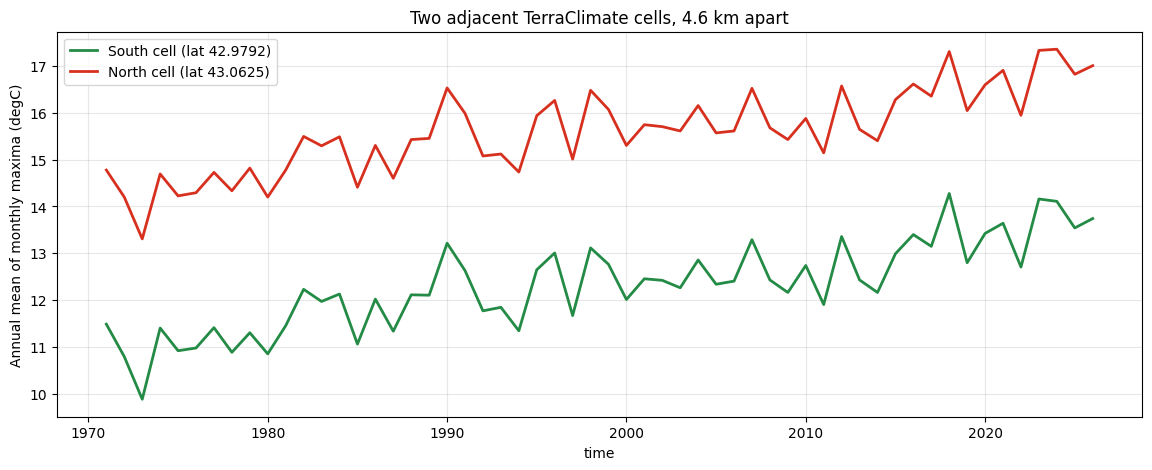

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(14, 5)

annual_south.plot.line(ax=ax, x='time', linewidth=2, color='#238b45',
                       label=f'South cell (lat {float(series.lat):.4f})')
annual_north.plot.line(ax=ax, x='time', linewidth=2, color='#d7301f',
                       label=f'North cell (lat {float(north.lat):.4f})')

ax.set_ylabel('Annual mean of monthly maxima (degC)')
ax.set_title('Two adjacent TerraClimate cells, 4.6 km apart')
ax.legend()
ax.grid(alpha=0.3)
plt.show()